# **✨Agent-Based Simulation of Indonesia's Power-Sector Carbon Tax✨**

This notebook develops an Agent-Based Simulation (ABS) platform to explore Indonesia’s emerging carbon-tax policy in the power sector, with a specific focus on coal-fired power plants (PLTU batubara). Climate-change mitigation has become a global priority, and Indonesia is preparing to implement a carbon pricing mechanism with the electricity sector as the pilot phase. Because the policy has complex and uncertain effects, simulation provides a structured way to test scenarios before real-world implementation.

The model is designed to integrate LLM-assisted rule extraction and ML-based analytics in the broader project workflow. In this notebook, we focus on constructing the core agent-based model from raw data to simulation outputs, using parameters and policy rules informed by LLM-assisted analysis..



## **🎯 Objectives and Research Question**

This project aims to develop an Agent-Based Simulation platform, enhanced with LLM and ML analytics, to explore the dynamics of various scenarios related to Indonesia's Carbon Tax in the Power Sector. 

**Research question:**

*How can an agent-based simulation platform, enhanced with LLM and ML analytics, be used to explore and analyse the dynamics of Indonesia’s carbon tax policy scenarios in the power sector?*

## **📃 Notebook structure**

1. Imports & setup  
2. Generic Rule Engine  
3. Action handlers (Government + Company)  
4. Global parameters & JSON rule loaders  
5. Merge clustering results into master plant dataset  
6. Reporting helpers
7. Agents (Government, Company, Plant, Customer, CarbonMarket)  
8. Model: CarbonTaxModel  
9. Runner: run_scenario  
10. Main: run 3 scenarios, create plots, export JSON + DOCX 


## **1. Imports & setup**

In [2]:
import os
import random
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import operator
import re
from datetime import date
import time
import platform
import sys

from mesa import Agent, Model
from mesa.space import MultiGrid

# Gemini SDK
from google import genai

# DOCX
from docx import Document
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

## **2. Generic Rule Engine**

### This section defines a compact rule engine that:
- Evaluates conditions safely from a JSON rule block
- Applies actions through handler functions
- Keeps policy logic configurable (without changing the model code)

In [3]:
OPS = {
    ">": operator.gt,
    "<": operator.lt,
    ">=": operator.ge,
    "<=": operator.le,
    "==": operator.eq,
    "!=": operator.ne,
}

class RuleEngine:
    SAFE_EXPR_RE = re.compile(r"^[0-9a-zA-Z_\s\.\*\+\-/\(\)]+$")

    @staticmethod
    def get_param(rule_block: dict, key: str, default=None):
        if key not in rule_block:
            return default
        v = rule_block[key]
        if isinstance(v, dict) and "value" in v:
            return v["value"]
        return v

    @classmethod
    def _eval_threshold(cls, cond: dict, rule_block: dict, ctx: dict):
        if "threshold_param" in cond:
            return cls.get_param(rule_block, cond["threshold_param"])
        if "threshold_expression" in cond:
            expr = cond["threshold_expression"]
            if not cls.SAFE_EXPR_RE.match(expr):
                raise ValueError(f"Unsafe threshold_expression: {expr}")
            return eval(expr, {"__builtins__": {}}, ctx)
        raise KeyError("Condition must have threshold_param or threshold_expression")

    @classmethod
    def check_condition(cls, cond: dict, rule_block: dict, ctx: dict) -> bool:
        op = cond["operator"]
        if op not in OPS:
            raise ValueError(f"Unsupported operator: {op}")

        var = cond["variable"]
        if var not in ctx:
            raise KeyError(f"Context missing variable: {var}")

        lhs = ctx[var]
        rhs = cls._eval_threshold(cond, rule_block, ctx)
        return OPS[op](lhs, rhs)

    @classmethod
    def evaluate_conditions(cls, rule_block: dict, ctx: dict):
        triggered = []
        for cond in rule_block.get("conditions", []):
            if cls.check_condition(cond, rule_block, ctx):
                triggered.append(cond["id"])
        return triggered

    @classmethod
    def apply_actions(cls, rule_block: dict, triggered_ids: list, ctx: dict, state: dict, handlers: dict):
        for act in rule_block.get("actions", []):
            if act.get("applies_when") not in triggered_ids:
                continue
            a_type = act.get("type")
            if a_type not in handlers:
                raise NotImplementedError(f"No handler for action type: {a_type}")
            handlers[a_type](act, rule_block, ctx, state)

    @classmethod
    def run_ruleblock(cls, rule_block: dict, ctx: dict, state: dict, handlers: dict):
        triggered = cls.evaluate_conditions(rule_block, ctx)
        cls.apply_actions(rule_block, triggered, ctx, state, handlers)
        return triggered


## **3. Action handlers (Government + Company)**

### 1) Government action handlers

These handlers implement how government policies update the tax rate:
- Step adjustments
- Partial alignment to the market allowance price


In [4]:
def gov_adjust_tax_rate(act, rule_block, ctx, state):
    step = RuleEngine.get_param(rule_block, act["step_param"])
    if act.get("direction") == "increase":
        state["tax_rate"] += step
    else:
        state["tax_rate"] -= step

def gov_partial_alignment(act, rule_block, ctx, state):
    factor = RuleEngine.get_param(rule_block, act["factor_param"])
    market_price = ctx["market_price"]
    tax_rate = state["tax_rate"]

    if "increase" in act.get("direction", ""):
        state["tax_rate"] += (market_price - tax_rate) * factor
    else:
        state["tax_rate"] -= (tax_rate - market_price) * factor

GOV_HANDLERS = {
    "adjust_tax_rate": gov_adjust_tax_rate,
    "partial_alignment": gov_partial_alignment,
}


### 2) Company action handlers (with cluster integration)

Key idea:
- Each plant has `cluster_id`
- Retrofit effectiveness uses per-cluster multipliers:
  `reduction_factor = base_reduction * cluster_multiplier`


In [5]:
def co_reduce_emission_intensity_and_heat_rate(act, rule_block, ctx, state):
    """
    SIMPLE CLUSTER INTEGRATION:
    - Each plant has p.cluster_id
    - Apply per-cluster multiplier to reduction_factor
    """
    trigger = RuleEngine.get_param(rule_block, "trigger_tax_above_min")
    max_reduce = RuleEngine.get_param(rule_block, "max_reduction_per_year")
    scale = RuleEngine.get_param(rule_block, "tax_to_reduction_scale")
    heat_mult = RuleEngine.get_param(rule_block, "heatrate_reduction_multiplier")
    pln_bias = RuleEngine.get_param(rule_block, "pln_adjustment_bias")
    ipp_bias = RuleEngine.get_param(rule_block, "ipp_adjustment_bias")

    excess_tax = ctx["tax_rate_minus_min_tax"] - trigger
    if excess_tax <= 0:
        return

    base_reduction = min(max_reduce, excess_tax / scale)
    base_reduction *= (pln_bias if state["is_pln"] else ipp_bias)

    inv_cost_unit = state["investment_cost_rp_per_mw_per_unit_rf"]
    period_inv = 0.0

    cluster_mult = state.get("cluster_retrofit_multiplier", {})
    default_mult = cluster_mult.get(-1, 1.0)

    for p in state["plants"]:
        cid = getattr(p, "cluster_id", -1)
        mult = cluster_mult.get(cid, default_mult)

        reduction_factor = base_reduction * mult
        reduction_factor = max(0.0, min(0.90, float(reduction_factor)))  # safety clamp

        p.emission_intensity *= (1.0 - reduction_factor)
        p.heat_rate_GJ_per_MWh *= (1.0 - heat_mult * reduction_factor)

        plant_inv_cost = inv_cost_unit * p.capacity_mw * reduction_factor
        period_inv += plant_inv_cost

        p.ppa_price_per_MWh = p._compute_ppa_price_per_MWh()

    state["period_investment_cost"] += period_inv

CO_HANDLERS = {
    "reduce_emission_intensity_and_heat_rate": co_reduce_emission_intensity_and_heat_rate,
}


## **4. Global parameters & JSON rule loaders**

### This block contains:
- price markups
- fuel/O&M/cost assumptions
- allowance market controls (floor/ceiling)
- offsets settings
- retrofit investment cost
- cluster retrofit multipliers

In [6]:
MODEL_PARAMS = {
    "price_normalization": 1_150_000.0,
    "ppa_markup": 0.10,
    "retail_markup": 0.10,

    "fuel_price_by_fuel": {"coal": 60_000},
    "variable_om_by_fuel": {"coal": 40_000},
    "fixed_lcoe_by_fuel": {"coal": 250_000},

    "allowance_price_init": 30.0,

    "auction_price_k": 0.35,
    "allowance_price_floor": 10.0,
    "allowance_price_ceiling": 500.0,

    "auction_share": 0.20,
    "benchmark_tighten_factor": 1.00,
    "auction_supply_capped_by_demand": False,

    "offset_enabled": True,
    "offset_price_discount": 0.80,
    "offset_supply_t_per_year": 5_000_000,
    "offset_use_limit_ratio": 0.10,
    "offset_limit_basis": "deficit",

    "investment_cost_rp_per_mw_per_unit_rf": 8_000_000_000,

    "cluster_retrofit_multiplier": {
        0: 1.00,
        1: 0.85,
        2: 1.30,
        3: 0.60,
        4: 1.50,
        -1: 1.00,
    }
}

def load_gov_rules(path="gov_rules_llm.json"):
    with open(path, "r") as f:
        return json.load(f)

def load_company_rules(path="company_rules_llm.json"):
    with open(path, "r") as f:
        return json.load(f)



## **5. Merge clustering results into master plant dataset**

### This helper:
- Reads the cluster CSV output
- Finds a stable join key shared with the master dataset
- Merges `cluster_kproto` into the master dataframe
- Plants without a match get cluster = `-1`


In [7]:
def merge_cluster_into_master(
    master_df: pd.DataFrame,
    cluster_csv_path: str,
    cluster_col: str = "cluster_kproto",
):
    cl = pd.read_csv(cluster_csv_path)

    if cluster_col not in cl.columns:
        raise KeyError(f"[Cluster CSV] Missing required column '{cluster_col}' in {cluster_csv_path}")

    candidates = [
        "GEM unit/phase ID",
        "GEM unit ID",
        "unit_id",
        "unitid",
        "Unit ID",
        "plant_id",
        "Plant ID",
    ]

    join_key = None
    for k in candidates:
        if k in master_df.columns and k in cl.columns:
            join_key = k
            break

    if join_key is None and "Plant name" in master_df.columns and "Plant name" in cl.columns:
        join_key = "Plant name"
        print("[WARN] Using 'Plant name' as join key. Prefer a stable ID like 'GEM unit/phase ID'.")

    if join_key is None:
        raise KeyError(
            "Cannot find a common join key between master CSV and cluster CSV.\n"
            f"Master columns: {list(master_df.columns)}\n"
            f"Cluster columns: {list(cl.columns)}\n"
            "Fix: ensure both files share an ID column (e.g., 'GEM unit/phase ID')."
        )

    cl_small = cl[[join_key, cluster_col]].copy()
    cl_small[cluster_col] = pd.to_numeric(cl_small[cluster_col], errors="coerce")

    out = master_df.merge(cl_small, on=join_key, how="left")

    missing = out[cluster_col].isna().sum()
    if missing > 0:
        print(f"[WARN] {missing} plants have no cluster match (cluster set to -1). Check join key '{join_key}'.")

    out[cluster_col] = out[cluster_col].fillna(-1).astype(int)
    return out



In [7]:
def merge_cluster_into_master(
    master_df: pd.DataFrame,
    cluster_csv_path: str,
    cluster_col: str = "cluster_kproto",
):
    cl = pd.read_csv(cluster_csv_path)

    if cluster_col not in cl.columns:
        raise KeyError(f"[Cluster CSV] Missing required column '{cluster_col}' in {cluster_csv_path}")

    candidates = [
        "GEM unit/phase ID",
        "GEM unit ID",
        "unit_id",
        "unitid",
        "Unit ID",
        "plant_id",
        "Plant ID",
    ]

    join_key = None
    for k in candidates:
        if k in master_df.columns and k in cl.columns:
            join_key = k
            break

    if join_key is None and "Plant name" in master_df.columns and "Plant name" in cl.columns:
        join_key = "Plant name"
        print("[WARN] Using 'Plant name' as join key. Prefer a stable ID like 'GEM unit/phase ID'.")

    if join_key is None:
        raise KeyError(
            "Cannot find a common join key between master CSV and cluster CSV.\n"
            f"Master columns: {list(master_df.columns)}\n"
            f"Cluster columns: {list(cl.columns)}\n"
            "Fix: ensure both files share an ID column (e.g., 'GEM unit/phase ID')."
        )

    cl_small = cl[[join_key, cluster_col]].copy()
    cl_small[cluster_col] = pd.to_numeric(cl_small[cluster_col], errors="coerce")

    out = master_df.merge(cl_small, on=join_key, how="left")

    missing = out[cluster_col].isna().sum()
    if missing > 0:
        print(f"[WARN] {missing} plants have no cluster match (cluster set to -1). Check join key '{join_key}'.")

    out[cluster_col] = out[cluster_col].fillna(-1).astype(int)
    return out


## **6. Reporting helpers**

## This section builds:
- KPI summaries per scenario
- A compact JSON packet for reproducibility + LLM input
- A policy brief (Gemini; fallback if not available)
- A Word report (.docx) including figures and appendix


In [9]:
def summarize_history(df: pd.DataFrame) -> dict:
    if df is None or df.empty:
        return {"error": "empty_history"}

    emis0 = float(df["total_emission"].iloc[0])
    emisT = float(df["total_emission"].iloc[-1])

    def pct(a, b):
        if a == 0:
            return None
        return float((b - a) / a * 100.0)

    kpi = {
        "steps": int(df["step"].iloc[-1]),

        "total_emission_start_t": emis0,
        "total_emission_end_t": emisT,
        "total_emission_change_pct": pct(emis0, emisT),

        "tax_rate_mean": float(df["tax_rate"].mean()),
        "tax_rate_min": float(df["tax_rate"].min()),
        "tax_rate_max": float(df["tax_rate"].max()),

        "allowance_price_mean": float(df["allowance_price"].mean()),
        "allowance_price_min": float(df["allowance_price"].min()),
        "allowance_price_max": float(df["allowance_price"].max()),
        "allowance_price_std": float(df["allowance_price"].std(ddof=0)),

        "gov_revenue_cumulative_end_Rp": float(df["gov_rev_cum"].iloc[-1]),
        "profit_cumulative_end_Rp": float(df["profit_cum_total"].iloc[-1]),
    }
    return kpi


def build_brief_packet(results: list) -> dict:
    packet = {
        "audience": "policy_decision_maker",
        "country_context": "Indonesia (coal power fleet)",
        "intended_readers": ["Ministry of Finance", "economic policy teams", "cross-ministry stakeholders"],
        "model_scope_plain_english": (
            "A simplified simulation that explores how carbon pricing policies could affect "
            "power-sector emissions, government revenue, and company profits over time. "
            "It uses only the outputs shown in the KPI tables below."
        ),
        "time_horizon_steps": None,
        "scenarios": [],
        "comparison": {}
    }

    for r in results:
        df = r["history"]
        kpi = summarize_history(df)
        if packet["time_horizon_steps"] is None and "steps" in kpi:
            packet["time_horizon_steps"] = kpi["steps"]
        packet["scenarios"].append({"name": r["name"], "kpi": kpi})

    def rank_by(key, reverse=False):
        rows = []
        for s in packet["scenarios"]:
            v = s["kpi"].get(key, None)
            if v is None:
                continue
            rows.append((s["name"], v))
        rows.sort(key=lambda x: x[1], reverse=reverse)
        return [{"rank": i+1, "scenario": n, "value": v} for i, (n, v) in enumerate(rows)]

    packet["comparison"] = {
        "emissions_end_rank_lowest_best": rank_by("total_emission_end_t", reverse=False),
        "gov_revenue_end_rank_highest_best": rank_by("gov_revenue_cumulative_end_Rp", reverse=True),
        "profit_end_rank_highest_best": rank_by("profit_cumulative_end_Rp", reverse=True),
        "allowance_price_volatility_rank_lowest_best": rank_by("allowance_price_std", reverse=False),
    }
    return packet


def generate_policy_brief_gemini(brief_packet: dict, model_name: str = "gemini-2.5-flash") -> str:
    api_key = os.environ.get("GEMINI_API_KEY")
    if not api_key:
        raise EnvironmentError("Missing GEMINI_API_KEY environment variable.")

    client = genai.Client(api_key=api_key)

    brief_text = json.dumps(brief_packet, indent=2)

    prompt = f"""
You are writing a ONE-PAGE POLICY BRIEF for senior government decision-makers in Indonesia
(e.g., Ministry of Finance, economic policy units).

Audience:
- Not technical
- No background in programming, modelling, or IT
- Interested in fiscal impacts, policy trade-offs, and risks
- Needs clear, plain English

IMPORTANT WRITING RULES:
- Use clear, simple English
- Short sentences
- Avoid jargon
- Explain concepts in everyday language
- Do NOT mention programming, Python, ABM, Mesa, models, or algorithms
- Do NOT invent numbers (use only numbers from the JSON)
- If something is missing, clearly say it is not available from the outputs
- Do NOT use markdown symbols like ** or *

VERY IMPORTANT ABOUT FIGURES:
- Figures will be placed AFTER the main text by the system.
- For each figure, write the explanation so that it reads naturally
  even if the figure appears immediately after the explanation.
- Do NOT say “see above” or “see below”.
- Write as if the figure appears right after the paragraph.

USE THIS EXACT STRUCTURE AND HEADINGS:

TITLE:
Policy Brief: Carbon Pricing Scenarios — Implications for Public Finance

Prepared for:
Government decision-makers (e.g., Ministry of Finance)

Prepared by:
Pratiwi Eka Sugiarti

Date:
2026-02-02

1) Why this matters
Provide 2–3 bullet points explaining why carbon pricing in the power sector
matters for emissions, public finance, and government budgeting.

2) What we tested
One short paragraph explaining, in plain language, that different carbon pricing
policy designs were compared over time, focusing on emissions, government revenue,
and company profits.

3) Key results
Bullet points summarising the main findings.
Use numbers from the JSON where available.

4) Figure explanations (integrated narrative)

Figure 1. Total emissions over time (tCO₂)
Write a short paragraph that explains:
- what the figure shows
- which scenario reduces emissions
- which scenarios do not
- why this matters for Indonesia’s climate targets
Write as if the figure appears immediately after this paragraph.

Figure 2. Government revenue over time — cumulative (Rp)
Write a short paragraph that explains:
- how government revenue differs across scenarios
- why stricter carbon limits increase revenue
- what this means for fiscal space and budget planning
Write as if the figure appears immediately after this paragraph.

Figure 3. Total company profit over time — cumulative (Rp)
Write a short paragraph that explains:
- how company profits change under different policies
- the trade-off between public revenue and company profits
- why this matters for investment and energy security
Write as if the figure appears immediately after this paragraph.

5) What it means for public finance (Ministry of Finance lens)
Bullet points focusing on:
- revenue potential
- fiscal trade-offs
- budget predictability
- policy credibility

6) Risks / trade-offs
Bullet points discussing risks in plain language, including:
- impacts on power companies
- price volatility
- risk of weak emission outcomes under mild policies

7) Recommended actions
Provide 3 clear, practical policy recommendations.
Avoid technical detail.

8) What to do next
Provide 2 realistic next steps for policymakers.

Appendix: KPI Briefing Packet (for transparency)
Briefly explain that the appendix summarises key indicators used to support
this policy brief. Do not reinterpret the numbers in detail.

JSON DATA:
{brief_text}
""".strip()

    resp = client.models.generate_content(
        model=model_name,
        contents=prompt
    )

    text = getattr(resp, "text", None)
    if not text:
        text = str(resp)
    return text


def fallback_policy_brief(brief_packet: dict) -> str:
    """If Gemini call fails, produce a basic non-technical brief from KPIs."""
    lines = []
    lines.append("POLICY BRIEF: Carbon Pricing Scenarios — Summary for Decision-Makers")
    lines.append("")
    lines.append("1) Why this matters")
    lines.append("- Indonesia is exploring carbon pricing to reduce emissions while protecting the economy.")
    lines.append("- This brief summarises how three policy settings could change emissions and public revenue over time.")
    lines.append("")
    lines.append("2) What we tested")
    lines.append("We compared three policy scenarios and tracked total emissions, carbon price signals, government revenue, and total company profit over a multi-year horizon.")
    lines.append("")
    lines.append("3) Key results")
    for s in brief_packet.get("scenarios", []):
        k = s.get("kpi", {})
        lines.append(f"- {s.get('name')}:")
        lines.append(f"  - Emissions (start→end): {k.get('total_emission_start_t', 'NA'):.2f} → {k.get('total_emission_end_t', 'NA'):.2f} tCO₂")
        ch = k.get("total_emission_change_pct", None)
        lines.append(f"  - Emissions change: {ch:.2f}% " if ch is not None else "  - Emissions change: not available")
        lines.append(f"  - Government revenue (cumulative, end): Rp {k.get('gov_revenue_cumulative_end_Rp', 0.0):,.0f}")
        lines.append(f"  - Company profit (cumulative, end): Rp {k.get('profit_cumulative_end_Rp', 0.0):,.0f}")
    lines.append("")
    lines.append("4) What it means for public finance (Ministry of Finance lens)")
    lines.append("- Higher carbon prices can raise public revenue, but may also increase energy costs if not managed.")
    lines.append("- Policy design should balance emissions reduction with affordability and economic competitiveness.")
    lines.append("")
    lines.append("5) Risks / trade-offs")
    lines.append("- If prices rise too quickly, companies and consumers may face cost pressures.")
    lines.append("- If prices are too low, emissions reductions may be limited.")
    lines.append("")
    lines.append("6) Recommended actions")
    lines.append("- Use a predictable price path (avoid sudden jumps).")
    lines.append("- Protect vulnerable groups and key sectors with targeted measures.")
    lines.append("- Monitor outcomes annually and adjust based on evidence.")
    lines.append("")
    lines.append("7) What to do next")
    lines.append("- Validate assumptions with stakeholders and update input data.")
    lines.append("- Extend analysis to include distributional impacts and sectoral competitiveness.")
    return "\n".join(lines)

def _add_inline_markdown_runs(paragraph, text: str):
    """
    Convert inline **bold** markers into real Word bold runs.
    Keeps it simple: only supports **bold**.
    """
    # Split by **...**
    parts = re.split(r"(\*\*.*?\*\*)", text)
    for part in parts:
        if not part:
            continue
        if part.startswith("**") and part.endswith("**") and len(part) >= 4:
            run = paragraph.add_run(part[2:-2])
            run.bold = True
        else:
            paragraph.add_run(part)


def _add_markdownish_text_to_docx(doc: Document, text: str):
    """
    Improved minimal parser:
    - Title lines (ALL CAPS or starts with "Policy Brief") -> Title style
    - "1) ..." -> Heading 1
    - Bullets: "- ..." or "* ..." or "• ..."
    - Inline bold: **...** -> real bold runs
    - Removes leftover markdown symbols cleanly
    """
    first_nonempty_done = False

    for raw in text.splitlines():
        line = raw.strip()

        if not line:
            doc.add_paragraph("")
            continue

        # If the line is like "**Heading**" alone, treat as normal heading text (strip **)
        if re.fullmatch(r"\*\*.+\*\*", line):
            line = line[2:-2].strip()

        # Title heuristics
        if not first_nonempty_done:
            # If Gemini already puts a title line, use it as Title
            if line.lower().startswith("policy brief"):
                p = doc.add_paragraph("")
                p.style = doc.styles["Title"]
                _add_inline_markdown_runs(p, line.replace("**", ""))
                first_nonempty_done = True
                continue

        if (line.upper() == line and len(line) < 140) or line.lower().startswith("policy brief:"):
            p = doc.add_paragraph("")
            p.style = doc.styles["Title"]
            _add_inline_markdown_runs(p, line.replace("**", ""))
            first_nonempty_done = True
            continue

        first_nonempty_done = True

        # Heading 1: "1) ..." format
        if re.match(r"^\d+\)\s+", line):
            p = doc.add_paragraph("")
            p.style = doc.styles["Heading 1"]
            _add_inline_markdown_runs(p, line.replace("**", ""))
            continue

        # Bullets: "- " or "* " or "• "
        if line.startswith("- ") or line.startswith("* ") or line.startswith("• "):
            bullet_text = line[2:].strip()
            # Remove accidental remaining markdown markers
            bullet_text = bullet_text.replace("**", "")
            p = doc.add_paragraph("", style="List Bullet")
            _add_inline_markdown_runs(p, bullet_text)
            continue

        # Normal paragraph: remove stray markdown markers but keep inline bold
        # (inline bold handled by _add_inline_markdown_runs)
        p = doc.add_paragraph("")
        _add_inline_markdown_runs(p, line)

def build_policy_brief_docx(
    policy_brief_text: str,
    brief_packet: dict,
    figure_paths: list,
    out_path: str = "decision_policy_brief.docx",
    author_name: str = "Pratiwi Eka Sugiarti",
):
    doc = Document()

    # Title block
    title = "Policy Brief: Carbon Pricing Scenarios — Implications for Public Finance"
    p = doc.add_paragraph(title)
    p.style = doc.styles["Title"]

    meta = doc.add_paragraph(f"Prepared for: Government decision-makers (e.g., Ministry of Finance)\n"
                             f"Prepared by: {author_name}\n"
                             f"Date: {date.today().isoformat()}")
    meta.paragraph_format.space_after = Pt(12)

    # Add the policy brief text
    _add_markdownish_text_to_docx(doc, policy_brief_text)

    # Figures section
    doc.add_page_break()
    h = doc.add_paragraph("Figures")
    h.style = doc.styles["Heading 1"]

    captions = [
        "Figure 1. Total emissions over time (tCO₂).",
        "Figure 2. Government revenue over time — cumulative (Rp).",
        "Figure 3. Total company profit over time — cumulative (Rp).",
    ]

    for i, fig in enumerate(figure_paths):
        if not os.path.exists(fig):
            doc.add_paragraph(f"[Missing figure file: {fig}]")
            continue
        cap = captions[i] if i < len(captions) else f"Figure {i+1}."
        doc.add_paragraph(cap).style = doc.styles["Heading 2"]
        doc.add_picture(fig, width=Inches(6.5))
        # Center the last added image paragraph
        last_par = doc.paragraphs[-1]
        last_par.alignment = WD_ALIGN_PARAGRAPH.CENTER
        doc.add_paragraph("")

    # Appendix: Briefing packet (optional but good for audit trail)
    doc.add_page_break()
    doc.add_paragraph("Appendix: KPI Briefing Packet (for transparency)").style = doc.styles["Heading 1"]
    doc.add_paragraph(
        "This appendix lists the compact KPI summary used to generate the policy brief. "
        "It supports reproducibility and review."
    )

    packet_text = json.dumps(brief_packet, indent=2)
    # put as smaller font
    pre = doc.add_paragraph(packet_text)
    for run in pre.runs:
        run.font.size = Pt(8)

    doc.save(out_path)
    print(f"[INFO] Saved DOCX: {out_path}")



## **7. Agents (Government, Company, Plant, Customer, CarbonMarket)**

## We define five agent types:
- **Government**: adjusts carbon tax rate using rule blocks
- **PowerCompany**: owns plants, earns profits, invests in retrofits uring rule blocks
- **PowerPlant**: produces electricity, emits CO₂, participates in allowance + offset + tax settlement
- **Customer**: demand responds to retail price (simple price elasticity)
- **CarbonMarket**: clears primary auction and offset market and updates allowance price


### Government Agent

In [10]:
class Government(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.rules = model.gov_rules

        self.tax_rate = self.rules["initial_tax_rate"]["value"]
        self.min_tax_rate = self.rules["min_tax_rate"]["value"]

        self.last_period_revenue = 0.0
        self.total_revenue = 0.0
        self.last_period_auction_revenue = 0.0
        self.total_auction_revenue = 0.0

    def step(self):
        total_emission = sum(p.emission for p in self.model.powerplants)
        emission_ratio = total_emission / self.model.emission_target if self.model.emission_target > 0 else 1.0
        market_price = self.model.carbon_market.allowance_price

        em_rule = self.rules["emission_adjustment"]
        ctx = {"emission_ratio": emission_ratio}
        state = {"tax_rate": self.tax_rate}
        RuleEngine.run_ruleblock(em_rule, ctx, state, GOV_HANDLERS)
        self.tax_rate = state["tax_rate"]

        if self.tax_rate < self.min_tax_rate:
            self.tax_rate = self.min_tax_rate

        ma_rule = self.rules["market_alignment"]
        ctx = {
            "market_price": market_price,
            "min_tax_rate": self.min_tax_rate,
            "upper_multiplier": RuleEngine.get_param(ma_rule, "upper_multiplier"),
        }
        state = {"tax_rate": self.tax_rate}
        RuleEngine.run_ruleblock(ma_rule, ctx, state, GOV_HANDLERS)
        self.tax_rate = state["tax_rate"]

        floor = max(self.min_tax_rate, market_price)
        if self.tax_rate < floor:
            self.tax_rate = floor


### PowerCompany Agent

- PLN dispatches the system (merit order) and earns retail revenue.
- IPPs earn PPA revenue.
- Investment decisions are applied using the rule engine (with cluster multipliers).


In [11]:
class PowerCompany(Agent):
    def __init__(self, model, name, is_pln=False):
        super().__init__(model)
        self.name = name
        self.is_pln = is_pln
        self.plants = []

        self.cum_profit = 0.0
        self.last_period_profit = 0.0
        self.last_period_investment_cost = 0.0
        self.cum_investment_cost = 0.0

        self.carbon_cashflow = 0.0
        self.last_period_offset_used_t = 0.0

        self.rules = model.company_rules
        self.investment_rules = self.rules["company_investment"]

    def step(self):
        period_operating_cost = 0.0
        period_revenue = 0.0
        period_investment_cost = 0.0

        self.carbon_cashflow = 0.0
        self.last_period_offset_used_t = 0.0

        for p in self.plants:
            p.step()
            period_operating_cost += p.variable_cost_excl_tax()
            period_operating_cost += p.fixed_cost_total()

        if self.is_pln:
            wholesale_cost = 0.0
            for co in self.model.powercompanies:
                if co is self:
                    continue
                for p in co.plants:
                    wholesale_cost += p.ppa_price_per_MWh * p.output_MWh

            served = self.model.total_output()
            period_revenue = self.model.retail_price * served
            period_profit = period_revenue - (wholesale_cost + period_operating_cost)
        else:
            period_revenue = sum(p.ppa_price_per_MWh * p.output_MWh for p in self.plants)
            period_profit = period_revenue - period_operating_cost

        gov = self.model.government
        tax_rate = gov.tax_rate
        min_tax = gov.min_tax_rate

        inv_rule = self.investment_rules

        ctx = {"tax_rate_minus_min_tax": (tax_rate - min_tax)}
        state = {
            "is_pln": self.is_pln,
            "plants": self.plants,
            "investment_cost_rp_per_mw_per_unit_rf": self.model.investment_cost_rp_per_mw_per_unit_rf,
            "period_investment_cost": 0.0,
            "cluster_retrofit_multiplier": self.model.cluster_retrofit_multiplier,
        }

        RuleEngine.run_ruleblock(inv_rule, ctx, state, CO_HANDLERS)
        period_investment_cost += state["period_investment_cost"]

        period_profit -= period_investment_cost

        self.last_period_profit = period_profit
        self.cum_profit += period_profit
        self.last_period_investment_cost = period_investment_cost
        self.cum_investment_cost += period_investment_cost

    def dispatch_system(self):
        if not self.is_pln:
            return

        demand = self.model.total_demand()
        tax_rate = self.model.government.tax_rate

        for p in self.model.powerplants:
            p.output_MWh = 0.0

        plants_sorted = sorted(self.model.powerplants, key=lambda p: p.marginal_cost_per_MWh(tax_rate))

        remaining = demand
        for p in plants_sorted:
            if remaining <= 0:
                break
            gen = min(p.max_output_MWh(), remaining)
            p.output_MWh = gen
            remaining -= gen

        self.model.unserved_demand = max(0.0, remaining)


### PowerPlant Agent

Each plant:
- Tracks emission intensity (tCO₂/MWh) and output
- Computes costs and PPA price
- Stores compliance settlement fields (free allowances, auction, offsets, residual tax)


In [12]:
class PowerPlant(Agent):
    def __init__(
        self, model, owner, unit_id, plant_name,
        capacity_mw, capacity_factor, annual_generation_MWh,
        emission_actual_t, emission_threshold_t, is_mine_mouth,
        fuel_type="coal",
        cluster_id=-1,
    ):
        super().__init__(model)
        self.owner = owner
        self.unit_id = unit_id
        self.plant_name = plant_name
        self.capacity_mw = float(capacity_mw)
        self.capacity_factor = float(capacity_factor)
        self.output_MWh = float(annual_generation_MWh)

        self.emission_threshold = float(emission_threshold_t) if emission_threshold_t is not None else 0.0
        self.is_mine_mouth = bool(is_mine_mouth)
        self.fuel_type = str(fuel_type).lower()

        try:
            self.cluster_id = int(cluster_id)
        except Exception:
            self.cluster_id = -1

        self.emission_intensity = (
            float(emission_actual_t) / float(annual_generation_MWh)
            if annual_generation_MWh and annual_generation_MWh > 0 else 0.0
        )
        self.heat_rate_GJ_per_MWh = self.emission_intensity / 0.0946 if self.emission_intensity > 0 else 11.0

        self.emission = float(emission_actual_t) if emission_actual_t is not None else 0.0
        self.ppa_price_per_MWh = self._compute_ppa_price_per_MWh()

        self.allowance_free_t = 0.0
        self.excess_emission_t = 0.0
        self.covered_by_auction_t = 0.0
        self.covered_by_offset_t = 0.0
        self.residual_taxed_t = 0.0

    def fuel_cost_per_MWh(self):
        fuel_price = self.model.fuel_price_by_fuel.get(self.fuel_type, self.model.default_fuel_price)
        return self.heat_rate_GJ_per_MWh * fuel_price

    def variable_om_per_MWh(self):
        return self.model.variable_om_by_fuel.get(self.fuel_type, self.model.default_variable_om)

    def variable_cost_excl_tax(self):
        return (self.fuel_cost_per_MWh() + self.variable_om_per_MWh()) * self.output_MWh

    def _compute_ppa_price_per_MWh(self):
        base = self.fuel_cost_per_MWh() + self.variable_om_per_MWh()
        fixed = self.model.fixed_lcoe_by_fuel.get(self.fuel_type, self.model.default_fixed_lcoe)
        return base * (1 + self.model.ppa_markup) + fixed

    def fixed_cost_total(self):
        fixed = self.model.fixed_lcoe_by_fuel.get(self.fuel_type, self.model.default_fixed_lcoe)
        return fixed * self.output_MWh

    def max_output_MWh(self):
        return self.capacity_mw * 8760 * self.capacity_factor

    def marginal_cost_per_MWh(self, tax_rate):
        carbon_cost = self.emission_intensity * 1000.0 * tax_rate
        return self.fuel_cost_per_MWh() + self.variable_om_per_MWh() + carbon_cost

    def step(self):
        self.emission = self.output_MWh * self.emission_intensity
        self.ppa_price_per_MWh = self._compute_ppa_price_per_MWh()

        self.excess_emission_t = 0.0
        self.covered_by_auction_t = 0.0
        self.covered_by_offset_t = 0.0
        self.residual_taxed_t = 0.0



### Customer Agent

Demand is adjusted byle price sensitivity:
- Higher retail price → lower demand
- Each customer gets a random sensitivity within a small range


In [13]:
class Customer(Agent):
    def __init__(self, model, base_demand, zone=None):
        super().__init__(model)
        self.base_demand = float(base_demand)
        self.zone = zone
        self.price_sensitivity = random.uniform(0.2, 0.4)
        self.demand = float(base_demand)

    def step(self):
        p_norm = self.model.retail_price / self.model.price_normalization
        self.demand = max(0.0, self.base_demand * (1 - self.price_sensitivity * (p_norm - 1.0)))


### CarbonMarket Agent

This market:
- Clears the **auction** (allowances sold by government)
- Optionally clears an **offset market** (limited usage)
- Updates allowance price based on supply-demand imbalance
- Applies floor/ceiling controls

In [14]:
class CarbonMarket(Agent):
    def __init__(self, model, init_price):
        super().__init__(model)
        self.allowance_price = float(init_price)
        self.k = float(MODEL_PARAMS["auction_price_k"])
        self.floor = float(MODEL_PARAMS["allowance_price_floor"])
        self.ceil = float(MODEL_PARAMS["allowance_price_ceiling"])

        self.offset_enabled = bool(MODEL_PARAMS["offset_enabled"])
        self.offset_discount = float(MODEL_PARAMS["offset_price_discount"])
        self.offset_supply_t_per_year = float(MODEL_PARAMS["offset_supply_t_per_year"])
        self.offset_use_limit_ratio = float(MODEL_PARAMS["offset_use_limit_ratio"])
        self.offset_limit_basis = str(MODEL_PARAMS["offset_limit_basis"]).lower()

        self.last_auction_supply_t = 0.0
        self.last_auction_demand_t = 0.0
        self.last_auction_sold_t = 0.0
        self.last_auction_value_rp = 0.0

        self.last_offset_used_t = 0.0
        self.last_offset_value_rp = 0.0

    def _clamp(self, x):
        return max(self.floor, min(self.ceil, x))

    @property
    def offset_price(self):
        return self._clamp(self.allowance_price * self.offset_discount)

    def clear_primary_auction(self, auction_volume_t):
        supply_nominal = max(0.0, float(auction_volume_t))
        buyers = [p for p in self.model.powerplants if p.excess_emission_t > 0]
        demand = sum(p.excess_emission_t for p in buyers)

        if MODEL_PARAMS.get("auction_supply_capped_by_demand", True):
            supply = min(supply_nominal, demand)
        else:
            supply = supply_nominal

        sold = min(supply, demand) if (supply > 0 and demand > 0) else 0.0

        cap = max(self.model.carbon_cap, 1.0)
        imbalance = (demand - supply) / cap
        self.allowance_price = self._clamp(self.allowance_price * (1.0 + self.k * imbalance))

        value_rp = 0.0
        if sold > 0 and demand > 0:
            px = self.allowance_price
            for p in buyers:
                buy_t = sold * (p.excess_emission_t / demand)
                buy_t = min(buy_t, p.excess_emission_t)

                p.covered_by_auction_t += buy_t
                p.excess_emission_t -= buy_t

                cost_rp = buy_t * 1000.0 * px
                value_rp += cost_rp
                p.owner.carbon_cashflow -= cost_rp

        self.last_auction_supply_t = supply
        self.last_auction_demand_t = demand
        self.last_auction_sold_t = sold
        self.last_auction_value_rp = value_rp
        return sold, value_rp

    def clear_offset_market(self):
        if not self.offset_enabled:
            self.last_offset_used_t = 0.0
            self.last_offset_value_rp = 0.0
            return 0.0, 0.0

        supply = max(0.0, self.offset_supply_t_per_year)
        buyers = [p for p in self.model.powerplants if p.excess_emission_t > 0]
        if supply <= 0 or not buyers:
            self.last_offset_used_t = 0.0
            self.last_offset_value_rp = 0.0
            return 0.0, 0.0

        limits = []
        total_limit = 0.0
        for p in buyers:
            if self.offset_limit_basis == "emission":
                lim = self.offset_use_limit_ratio * max(p.emission, 0.0)
            else:
                lim = self.offset_use_limit_ratio * max(p.excess_emission_t, 0.0)

            lim = max(0.0, min(lim, p.excess_emission_t))
            limits.append(lim)
            total_limit += lim

        used = min(supply, total_limit) if total_limit > 0 else 0.0
        if used <= 0:
            self.last_offset_used_t = 0.0
            self.last_offset_value_rp = 0.0
            return 0.0, 0.0

        px = self.offset_price
        value_rp = 0.0
        for p, lim in zip(buyers, limits):
            if lim <= 0:
                continue
            use_t = used * (lim / total_limit)
            use_t = min(use_t, p.excess_emission_t)

            p.covered_by_offset_t += use_t
            p.excess_emission_t -= use_t

            cost_rp = use_t * 1000.0 * px
            value_rp += cost_rp
            p.owner.carbon_cashflow -= cost_rp
            p.owner.last_period_offset_used_t += use_t

        self.last_offset_used_t = used
        self.last_offset_value_rp = value_rp
        return used, value_rp


## **8. Model: CarbonTaxModel**

## This model wires together:
- Data loading (master coal plants + cluster merge + energy demand)
- Agent creation and placement
- Allowance allocation (free vs auction share)
- Dispatch (PLN), investment, compliance settlement
- Tracking of key outputs (emissions, prices, revenue, profit)


In [15]:
class CarbonTaxModel(Model):
    def __init__(
        self,
        coal_dataset_path="indonesia_coal_plants_operating_enriched.csv",
        cluster_dataset_path="coal_plants_with_kprototypes.csv",
        energy_dataset_path="annual_energy_by_zone_2015_2024_FIXED.csv",
        width=100,
        height=100,
        emission_target_factor=0.95,
        carbon_cap_factor=1.05,
        verbose=True,
    ):
        super().__init__()
        self.verbose = bool(verbose)
        self.grid = MultiGrid(width, height, torus=True)

        self.gov_rules = load_gov_rules()
        self.company_rules = load_company_rules()

        p = MODEL_PARAMS
        self.price_normalization = p["price_normalization"]
        self.retail_price = self.price_normalization

        self.ppa_markup = p["ppa_markup"]
        self.retail_markup = p["retail_markup"]

        self.fuel_price_by_fuel = p["fuel_price_by_fuel"]
        self.default_fuel_price = p["fuel_price_by_fuel"]["coal"]

        self.variable_om_by_fuel = p["variable_om_by_fuel"]
        self.default_variable_om = p["variable_om_by_fuel"]["coal"]

        self.fixed_lcoe_by_fuel = p["fixed_lcoe_by_fuel"]
        self.default_fixed_lcoe = p["fixed_lcoe_by_fuel"]["coal"]

        self.investment_cost_rp_per_mw_per_unit_rf = p["investment_cost_rp_per_mw_per_unit_rf"]

        self.auction_share = max(0.0, min(1.0, float(p["auction_share"])))
        self.benchmark_tighten_factor = float(p["benchmark_tighten_factor"])

        self.cluster_retrofit_multiplier = dict(p.get("cluster_retrofit_multiplier", {-1: 1.0}))

        df_master = pd.read_csv(coal_dataset_path)
        df = merge_cluster_into_master(df_master, cluster_dataset_path, cluster_col="cluster_kproto")

        required_cols = ["emission_actual", "annual_generation_MWh", "owner", "capacity_mw", "capacity_factor",
                         "Plant name", "GEM unit/phase ID", "is_mine_mouth"]
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            raise KeyError(
                "MASTER dataset missing required columns: "
                + ", ".join(missing_cols)
                + "\nFix: use the enriched master CSV as coal_dataset_path."
            )

        baseline_total_emission = df["emission_actual"].sum()
        self.emission_target = emission_target_factor * baseline_total_emission
        self.carbon_cap = carbon_cap_factor * baseline_total_emission

        baseline_total_output = df["annual_generation_MWh"].sum()
        self.benchmark_intensity_t_per_MWh = (
            baseline_total_emission / baseline_total_output if baseline_total_output > 0 else 0.0
        )

        self.powercompanies = []
        self.powerplants = []
        self.customers = []

        self.government = Government(self)
        self.carbon_market = CarbonMarket(self, init_price=p["allowance_price_init"])

        self.grid.place_agent(self.government, self.random_empty_cell())
        self.grid.place_agent(self.carbon_market, self.random_empty_cell())

        owner_to_company = {}
        pln_company = None

        for owner_name in df["owner"].unique():
            name_str = str(owner_name)
            is_pln = "pln" in name_str.lower()
            if is_pln:
                if pln_company is None:
                    pln_company = PowerCompany(self, name="PLN", is_pln=True)
                    self.powercompanies.append(pln_company)
                    self.grid.place_agent(pln_company, self.random_empty_cell())
            else:
                co = PowerCompany(self, name=name_str, is_pln=False)
                self.powercompanies.append(co)
                owner_to_company[name_str] = co
                self.grid.place_agent(co, self.random_empty_cell())

        if pln_company is None:
            pln_company = PowerCompany(self, name="PLN", is_pln=True)
            self.powercompanies.append(pln_company)
            self.grid.place_agent(pln_company, self.random_empty_cell())

        for _, row in df.iterrows():
            owner_name = str(row["owner"])
            owner = pln_company if "pln" in owner_name.lower() else owner_to_company.get(owner_name)
            if owner is None:
                owner = PowerCompany(self, name=owner_name, is_pln=False)
                self.powercompanies.append(owner)
                owner_to_company[owner_name] = owner
                self.grid.place_agent(owner, self.random_empty_cell())

            plant = PowerPlant(
                model=self,
                owner=owner,
                unit_id=row["GEM unit/phase ID"],
                plant_name=row["Plant name"],
                capacity_mw=row["capacity_mw"],
                capacity_factor=row["capacity_factor"],
                annual_generation_MWh=row["annual_generation_MWh"],
                emission_actual_t=row["emission_actual"],
                emission_threshold_t=row.get("emission_threshold", 0.0),
                is_mine_mouth=row["is_mine_mouth"],
                fuel_type="coal",
                cluster_id=row.get("cluster_kproto", -1),
            )
            owner.plants.append(plant)
            self.powerplants.append(plant)
            self.grid.place_agent(plant, self.random_empty_cell())

        energy_df = pd.read_csv(energy_dataset_path)
        latest_year = energy_df["year"].max()
        energy_latest = energy_df[energy_df["year"] == latest_year]

        total_output_MWh = df["annual_generation_MWh"].sum()
        total_energy_MWh = energy_latest["energy_GWh"].sum() * 1000.0
        demand_scale = total_output_MWh / total_energy_MWh if total_energy_MWh > 0 else 1.0

        if self.verbose:
            print(
                f"[DEBUG] total_output={total_output_MWh:.0f} MWh, "
                f"total_demand0={total_energy_MWh:.0f} MWh, scale={demand_scale:.3f}"
            )
     
        for _, row in energy_latest.iterrows():
            base_demand_MWh = row["energy_GWh"] * 1000.0 * demand_scale
            cust = Customer(self, base_demand=base_demand_MWh, zone=row["zone"])
            self.customers.append(cust)
            self.grid.place_agent(cust, self.random_empty_cell())

        self.allocate_free_allowances()
        self.update_retail_price()

        self.step_num = 0
        self.last_auction_revenue_rp = 0.0
        self.last_offset_value_rp = 0.0
        self.last_backstop_tax_rp = 0.0
        self.unserved_demand = 0.0

    def random_empty_cell(self):
        return (self.random.randrange(self.grid.width), self.random.randrange(self.grid.height))

    def total_demand(self):
        return sum(c.demand for c in self.customers)

    def total_output(self):
        return sum(p.output_MWh for p in self.powerplants)

    def total_emission(self):
        return sum(p.emission for p in self.powerplants)

    def update_retail_price(self):
        out = self.total_output()
        if out <= 0:
            return
        total_ppa_value = sum(p.ppa_price_per_MWh * p.output_MWh for p in self.powerplants)
        carbon_cost = getattr(self, "last_total_carbon_cost", 0.0)
        total_system_cost = total_ppa_value + carbon_cost
        self.retail_price = (total_system_cost / out) * (1 + self.retail_markup)

    def allocate_free_allowances(self):
        total_out = sum(max(p.output_MWh, 0.0) for p in self.powerplants)
        if total_out <= 0:
            return

        benchmark = self.benchmark_intensity_t_per_MWh * self.benchmark_tighten_factor
        raw = [benchmark * max(p.output_MWh, 0.0) for p in self.powerplants]
        raw_sum = sum(raw)
        if raw_sum <= 0:
            return

        free_cap = (1.0 - self.auction_share) * self.carbon_cap
        scale = free_cap / raw_sum
        for p, r in zip(self.powerplants, raw):
            p.allowance_free_t = r * scale

    def compute_positions_after_free(self):
        for p in self.powerplants:
            p.excess_emission_t = max(0.0, p.emission - p.allowance_free_t)
            p.covered_by_auction_t = 0.0
            p.covered_by_offset_t = 0.0
            p.residual_taxed_t = 0.0

    def apply_backstop_tax(self):
        tax_rate = self.government.tax_rate
        total_tax = 0.0
        for p in self.powerplants:
            residual_t = max(0.0, p.excess_emission_t)
            p.residual_taxed_t = residual_t
            tax_rp = residual_t * 1000.0 * tax_rate
            total_tax += tax_rp

            p.owner.last_period_profit -= tax_rp
            p.owner.cum_profit -= tax_rp

        self.government.last_period_revenue += total_tax
        self.government.total_revenue += total_tax
        return total_tax

    def step(self):
        self.step_num += 1

        self.government.last_period_revenue = 0.0
        self.government.last_period_auction_revenue = 0.0
        total_carbon_system_cost = 0.0

        for c in self.customers:
            c.step()

        for co in self.powercompanies:
            if co.is_pln:
                co.dispatch_system()
                break

        self.allocate_free_allowances()

        for co in self.powercompanies:
            co.step()

        self.compute_positions_after_free()

        auction_supply_t = self.auction_share * self.carbon_cap
        sold_t, auction_value_rp = self.carbon_market.clear_primary_auction(auction_supply_t)
        total_carbon_system_cost += auction_value_rp

        self.government.step()

        self.government.last_period_auction_revenue = auction_value_rp
        self.government.total_auction_revenue += auction_value_rp
        self.government.last_period_revenue += auction_value_rp
        self.government.total_revenue += auction_value_rp

        offset_used_t, offset_value_rp = self.carbon_market.clear_offset_market()
        total_carbon_system_cost += offset_value_rp

        backstop_tax_rp = self.apply_backstop_tax()
        total_carbon_system_cost += backstop_tax_rp

        for co in self.powercompanies:
            co.last_period_profit += co.carbon_cashflow
            co.cum_profit += co.carbon_cashflow

        self.update_retail_price()

        self.last_auction_revenue_rp = auction_value_rp
        self.last_offset_value_rp = offset_value_rp
        self.last_backstop_tax_rp = backstop_tax_rp
        self.last_total_carbon_cost = total_carbon_system_cost

        total_emis = self.total_emission()
        total_out = self.total_output()
        total_dem = self.total_demand()
        unserved = max(0.0, total_dem - total_out)
        served_ratio = (total_out / total_dem) if total_dem > 0 else 1.0
        sys_intensity = (total_emis / total_out) if total_out > 0 else 0.0

        period_profit_total = sum(co.last_period_profit for co in self.powercompanies)
        cum_profit_total = sum(co.cum_profit for co in self.powercompanies)

        period_inv_total = sum(getattr(co, "last_period_investment_cost", 0.0) for co in self.powercompanies)
        cum_inv_total = sum(getattr(co, "cum_investment_cost", 0.0) for co in self.powercompanies)

        off_px = self.carbon_market.offset_price if self.carbon_market.offset_enabled else 0.0

        if self.verbose:
            print(
                f"Step {self.step_num:3d} | TotalEmis: {total_emis:12.2f} "
                f"| SysInt: {sys_intensity:7.4f} "
                f"| Tax: {self.government.tax_rate:6.1f} "
                f"| AllowPx: {self.carbon_market.allowance_price:6.1f} "
                f"| OffPx: {off_px:6.1f} "
                f"| Retail: {self.retail_price:10.2f} "
                f"| Demand: {total_dem:12.0f} "
                f"| Output: {total_out:12.0f} "
                f"| Unserved: {unserved:10.0f} "
                f"| Served%: {served_ratio*100:6.2f} "
                f"| AuctionRev(Rp): {auction_value_rp:14.2f} "
                f"| OffUsed(t): {offset_used_t:10.2f} "
                f"| OffValue(Rp): {offset_value_rp:14.2f} "
                f"| TaxBackstop(Rp): {backstop_tax_rp:14.2f} "
                f"| GovRev(yr): {self.government.last_period_revenue:14.2f} "
                f"| GovRev(cum): {self.government.total_revenue:14.2f} "
                f"| Inv(yr): {period_inv_total:14.2f} "
                f"| Inv(cum): {cum_inv_total:14.2f} "
                f"| Profit(yr): {period_profit_total:14.2f} "
                f"| Profit(cum): {cum_profit_total:14.2f}"
            )


## **9. Runner: run_scenario**

## Scenario runner:
- Initializes the model with scenario-specific target/cap factors
- Runs the simulation for `steps`
- Returns a tidy history dataframe for plotting + KPI summarisation


In [16]:
def runtime_env_info() -> dict:
    return {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "processor": platform.processor() or "unknown",
        "machine": platform.machine(),
    }

def run_scenario(
    name,
    coal_dataset_path="indonesia_coal_plants_operating_enriched.csv",
    cluster_dataset_path="coal_plants_with_kprototypes.csv",
    energy_dataset_path="annual_energy_by_zone_2015_2024_FIXED.csv",
    emission_target_factor=0.95,
    carbon_cap_factor=1.05,
    steps=30,
    verbose=False,
):
    print(f"\n=== Scenario: {name} ===")
    random.seed(42)
    np.random.seed(42)

    t0 = time.perf_counter()  # <-- ADD

    model = CarbonTaxModel(
        coal_dataset_path=coal_dataset_path,
        cluster_dataset_path=cluster_dataset_path,
        energy_dataset_path=energy_dataset_path,
        emission_target_factor=emission_target_factor,
        carbon_cap_factor=carbon_cap_factor,
        verbose=verbose,
    )
    env = runtime_env_info()
    counts = {
        "n_plants": len(model.powerplants),
        "n_companies": len(model.powercompanies),
        "n_customers": len(model.customers),
    }
    history = {
        "step": [],
        "total_emission": [],
        "allowance_price": [],
        "tax_rate": [],
        "gov_rev_annual": [],
        "gov_rev_cum": [],
        "profit_annual_total": [],
        "profit_cum_total": [],
    }

    for t in range(steps):
        model.step()

        history["step"].append(t + 1)
        history["total_emission"].append(model.total_emission())
        history["allowance_price"].append(model.carbon_market.allowance_price)
        history["tax_rate"].append(model.government.tax_rate)

        history["gov_rev_annual"].append(model.government.last_period_revenue)
        history["gov_rev_cum"].append(model.government.total_revenue)

        profit_annual = sum(co.last_period_profit for co in model.powercompanies)
        profit_cum = sum(co.cum_profit for co in model.powercompanies)
        history["profit_annual_total"].append(profit_annual)
        history["profit_cum_total"].append(profit_cum)

    t1 = time.perf_counter()  # <-- ADD
    runtime_s = t1 - t0       # <-- ADD

    df_hist = pd.DataFrame(history)

    # Optional: average time per simulated year/step
    avg_step_s = runtime_s / max(steps, 1)

    print(
        f"[RUNTIME] {name}: {runtime_s:.3f} s total | {avg_step_s:.4f} s/step "
        f"| plants={counts['n_plants']} companies={counts['n_companies']} customers={counts['n_customers']} "
        f"| python={env['python']} | machine={env['machine']} | cpu={env['processor']}"
    )
    return {
        "name": name,
        "history": df_hist,
        "runtime_s": float(runtime_s),      
        "avg_step_s": float(avg_step_s),   
        "steps": int(steps),  
        "counts": counts,  
        "env": env,        
    }

## **10. Main: run 3 scenarios, create plots, export JSON + DOCX**

## This final section:
- Runs 3 scenarios (baseline / stringent target / tight cap)
- Produces 3 figures:
  - `plot_total_emission.png`
  - `plot_gov_rev_cum.png`
  - `plot_profit_cum.png`
- Exports:
  - `decision_report_brief.json`
  - `decision_policy_brief.docx`dix


=== Scenario: Base policy (95% target) ===
[RUNTIME] Base policy (95% target): 0.260 s total | 0.0087 s/step | plants=276 companies=79 customers=5 | python=3.11.7 | machine=AMD64 | cpu=Intel64 Family 6 Model 142 Stepping 9, GenuineIntel

=== Scenario: More stringent target (80% baseline) ===
[RUNTIME] More stringent target (80% baseline): 0.143 s total | 0.0048 s/step | plants=276 companies=79 customers=5 | python=3.11.7 | machine=AMD64 | cpu=Intel64 Family 6 Model 142 Stepping 9, GenuineIntel

=== Scenario: Tight carbon cap (90% cap) ===
[RUNTIME] Tight carbon cap (90% cap): 0.165 s total | 0.0055 s/step | plants=276 companies=79 customers=5 | python=3.11.7 | machine=AMD64 | cpu=Intel64 Family 6 Model 142 Stepping 9, GenuineIntel

[RUNTIME] All scenarios total: 0.571 s
[RUNTIME] Base policy (95% target): 0.260 s (avg 0.0087 s/step, steps=30)
[RUNTIME] More stringent target (80% baseline): 0.143 s (avg 0.0048 s/step, steps=30)
[RUNTIME] Tight carbon cap (90% cap): 0.165 s (avg 0.0055 

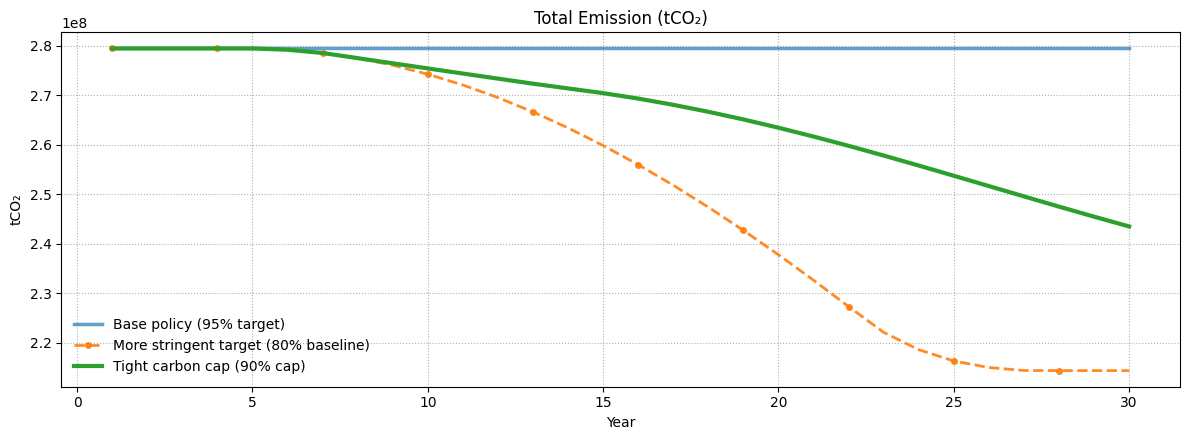

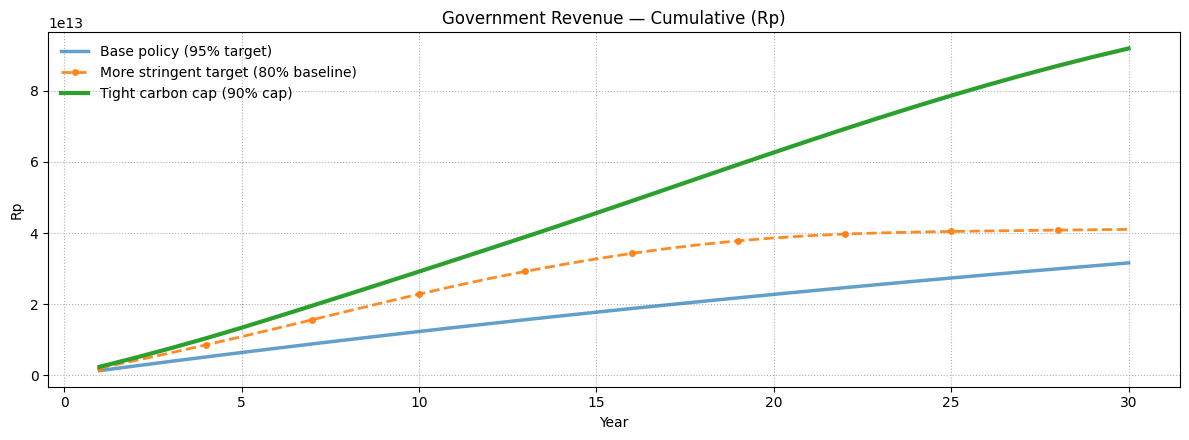

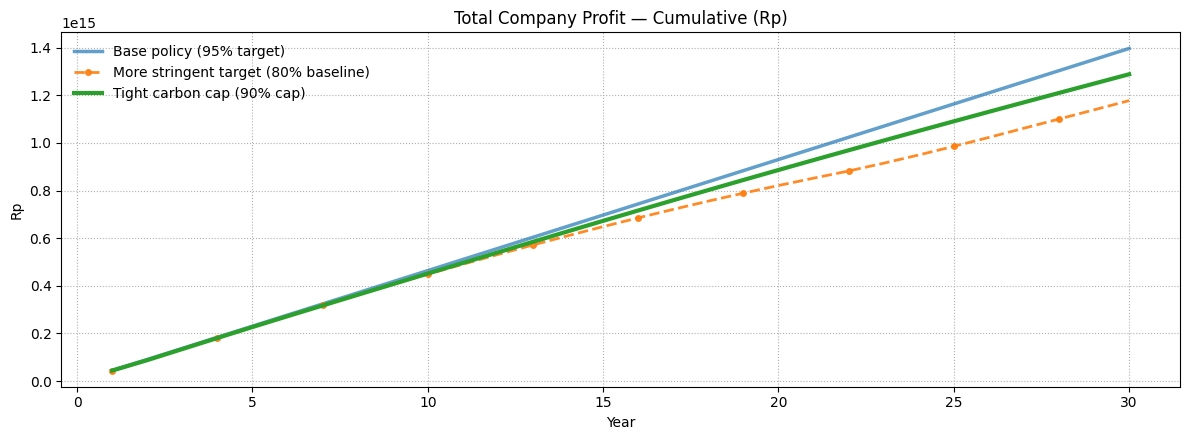

[INFO] Saved KPI packet: decision_report_brief.json
[INFO] Gemini policy brief generated.
[INFO] Saved DOCX: decision_policy_brief.docx


In [17]:
if __name__ == "__main__":
    t_all0 = time.perf_counter()
    # 1) Run scenarios
    results = []
    results.append(run_scenario(
        "Base policy (95% target)",
        emission_target_factor=0.95,
        carbon_cap_factor=1.05,
        steps=30,
        verbose=False,
    ))
    results.append(run_scenario(
        "More stringent target (80% baseline)",
        emission_target_factor=0.80,
        carbon_cap_factor=0.95,
        steps=30,
        verbose=False,
    ))
    results.append(run_scenario(
        "Tight carbon cap (90% cap)",
        emission_target_factor=0.95,
        carbon_cap_factor=0.90,
        steps=30,
        verbose=False,
    ))
    t_all1 = time.perf_counter()
    total_runtime_s = t_all1 - t_all0
    print(f"\n[RUNTIME] All scenarios total: {total_runtime_s:.3f} s")

    # Optional: print per-scenario summary table
    for r in results:
        print(f"[RUNTIME] {r['name']}: {r.get('runtime_s', 0.0):.3f} s "
              f"(avg {r.get('avg_step_s', 0.0):.4f} s/step, steps={r.get('steps', 'NA')})")
        
    # 2) Make plots and SAVE as PNG
    styles = {
        "Base policy (95% target)": dict(linestyle="-", linewidth=2.5, alpha=0.7, zorder=2),
        "More stringent target (80% baseline)": dict(linestyle="--", linewidth=2, marker="o", markersize=4, markevery=3, alpha=0.9, zorder=3),
        "Tight carbon cap (90% cap)": dict(linestyle="-", linewidth=3, alpha=1.0, zorder=4),
    }

    # Plot 1: Total Emission
    plt.figure(figsize=(12, 4.5))
    for r in results:
        h = r["history"]
        plt.plot(h["step"], h["total_emission"], label=r["name"], **styles[r["name"]])
    plt.title("Total Emission (tCO₂)")
    plt.xlabel("Year")
    plt.ylabel("tCO₂")
    plt.grid(True, linestyle=":")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("plot_total_emission.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Plot 2: Government Revenue (CUMULATIVE)
    plt.figure(figsize=(12, 4.5))
    for r in results:
        h = r["history"]
        plt.plot(h["step"], h["gov_rev_cum"], label=r["name"], **styles[r["name"]])
    plt.title("Government Revenue — Cumulative (Rp)")
    plt.xlabel("Year")
    plt.ylabel("Rp")
    plt.grid(True, linestyle=":")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("plot_gov_rev_cum.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Plot 3: Total Company Profit (CUMULATIVE)
    plt.figure(figsize=(12, 4.5))
    for r in results:
        h = r["history"]
        plt.plot(h["step"], h["profit_cum_total"], label=r["name"], **styles[r["name"]])
    plt.title("Total Company Profit — Cumulative (Rp)")
    plt.xlabel("Year")
    plt.ylabel("Rp")
    plt.grid(True, linestyle=":")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("plot_profit_cum.png", dpi=200, bbox_inches="tight")
    plt.show()

    figure_paths = ["plot_total_emission.png", "plot_gov_rev_cum.png", "plot_profit_cum.png"]

    # 3) Build briefing packet (KPI) and save for transparency
    brief_packet = build_brief_packet(results)
    with open("decision_report_brief.json", "w", encoding="utf-8") as f:
        json.dump(brief_packet, f, indent=2)
    print("[INFO] Saved KPI packet: decision_report_brief.json")

    # 4) Generate policy brief text with Gemini (fallback if error)
    try:
        policy_text = generate_policy_brief_gemini(brief_packet, model_name="gemini-2.5-flash")
        print("[INFO] Gemini policy brief generated.")
    except Exception as e:
        print(f"[WARN] Gemini call failed, using fallback policy brief. Reason: {e}")
        policy_text = fallback_policy_brief(brief_packet)

    # 5) Build DOCX
    build_policy_brief_docx(
        policy_brief_text=policy_text,
        brief_packet=brief_packet,
        figure_paths=figure_paths,
        out_path="decision_policy_brief.docx",
        author_name="Pratiwi Eka Sugiarti",
    )
